In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [3]:
SYSTEM_PROMPT = """
    Act as a helpful assistant.
    YOu run in a loop of thought, Action, Pause, Observation.
    At the end of the loop, you output an Answer.
    Use Thought to describe your thoughts about the question you have been asked.
    Use Actions to run one of the actions available to you - then return PAUSE.
    Observation will be the result of running those actions.
    Repeat till you get to the answer for the given user query.

    Use the following workflow format.
    Question: the input task you must solve
    Thought: you should always think about what to do
    Action: the action to take which can be any of the following:
        - break it into smaller steps if needed
        - see if you can answer the given task with your trained knowledge
        - calll the most relevant tool at your disposal mentioned below in case you need more information
    Action Input: the input to the action
    Observation: the result of the action
    ...(this Thought/Action/Acyion Input/Observation can repeat N times)

    Thought: I now know the final answer
    Final Answer: the final answer to the original input question

    Tools at your disposal to perform tasks as needed:
    - get_weather: whenever user asks get the weather of a place.
    - search_web_extract_info: whenever user asks for specific information or if you dont't know the answer.
    
"""

In [4]:
prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system",SYSTEM_PROMPT),
        MessagesPlaceholder(variable_name='history', optional=True),
        ("human","{query}"),
        MessagesPlaceholder(variable_name='agent_scratchpad'),
    ]
)

In [14]:
import requests
from langchain_core.tools import tool


@tool
def get_weather(query:str)->list:
    """Search weatherapi to get the current weather."""
    base_url = "https://api.openweathermap.org/data/2.5/weather"
    complete_url = f"{base_url}?q={query}&APPID={os.environ.get('WEATHER_API_KEY')}"

    response = requests.get(complete_url)
    data = response.json()

    print(complete_url)
    print(data)
    if data.get('name'):
        return data
    else:
        return "weather data not found"
        

In [72]:
from langchain_core.prompts import ChatPromptTemplate
from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent

In [16]:
from langchain_openai import ChatOpenAI
llm_gpt = ChatOpenAI(model='gpt-4o', temperature=0)

tools = [get_weather]

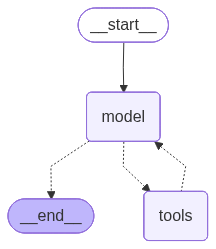

In [74]:
# agent_executor = create_react_agent(
#     model=llm_gpt, 
#     tools=tools,
#     state_modifier=prompt_template
# )

agent_executor = create_agent(
    model=llm_gpt,
    tools=tools,
    system_prompt = SYSTEM_PROMPT
)

agent_executor

In [23]:
inputs = {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
for chunk in agent_executor.stream(inputs, stream_mode="updates"):
    print(chunk)

{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 343, 'total_tokens': 358, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_45063aec59', 'id': 'chatcmpl-DVgkujGsbrvca5EJC1FNmgup0HbQ8', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d9c5d-e060-7250-9699-90c18e69f60a-0', tool_calls=[{'name': 'get_weather', 'args': {'query': 'San Francisco'}, 'id': 'call_HeynjUYXnAGJl5SvMMdU5dJp', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 343, 'output_tokens': 15, 'total_tokens': 358, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, '

In [26]:
inputs = {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
response = agent_executor.invoke(inputs, stream_mode="updates")
response

https://api.openweathermap.org/data/2.5/weather?q=San Francisco&APPID=8ce32efc60500f625bb6c5983ce35bee
{'coord': {'lon': -122.4194, 'lat': 37.7749}, 'weather': [{'id': 801, 'main': 'Clouds', 'description': 'few clouds', 'icon': '02d'}], 'base': 'stations', 'main': {'temp': 289.66, 'feels_like': 288.1, 'temp_min': 288.07, 'temp_max': 290.69, 'pressure': 1019, 'humidity': 28, 'sea_level': 1019, 'grnd_level': 1015}, 'visibility': 10000, 'wind': {'speed': 4.63, 'deg': 40}, 'clouds': {'all': 20}, 'dt': 1776444653, 'sys': {'type': 2, 'id': 2017837, 'country': 'US', 'sunrise': 1776432684, 'sunset': 1776480394}, 'timezone': -25200, 'id': 5391959, 'name': 'San Francisco', 'cod': 200}


[{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 343, 'total_tokens': 358, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_45063aec59', 'id': 'chatcmpl-DVgmIUn5vOwnxCJDzMXd0SMmJkXNq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d9c5f-3199-7380-a81a-b7610dcad333-0', tool_calls=[{'name': 'get_weather', 'args': {'query': 'San Francisco'}, 'id': 'call_Yiv74NYKmc1OKMXKAmUC2FPx', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 343, 'output_tokens': 15, 'total_tokens': 358, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 

In [32]:
def ask_agent(query: str):
    # We wrap the string into the required dictionary format here
    inputs = {"messages": [("human", query)]}
    response = agent_executor.invoke(inputs)
    print(response)

ask_agent("current weather in delhi")
    

https://api.openweathermap.org/data/2.5/weather?q=Delhi&APPID=8ce32efc60500f625bb6c5983ce35bee
{'coord': {'lon': 77.2167, 'lat': 28.6667}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 303.2, 'feels_like': 302.37, 'temp_min': 303.2, 'temp_max': 303.2, 'pressure': 1009, 'humidity': 35, 'sea_level': 1009, 'grnd_level': 981}, 'visibility': 4000, 'wind': {'speed': 7.72, 'deg': 320, 'gust': 20.58}, 'clouds': {'all': 100}, 'dt': 1776445453, 'sys': {'type': 1, 'id': 9165, 'country': 'IN', 'sunrise': 1776385423, 'sunset': 1776431845}, 'timezone': 19800, 'id': 1273294, 'name': 'Delhi', 'cod': 200}
{'messages': [HumanMessage(content='current weather in delhi', additional_kwargs={}, response_metadata={}, id='dd8ad8c9-c747-43a8-9abb-8da2034554b0'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 342, 'total_tokens': 356, 'comple

In [27]:
# Multi user system

In [28]:
from langchain_community.chat_message_histories import SQLChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

In [47]:
def get_session_history_db(session_id):
    return SQLChatMessageHistory(session_id,"sqlite:///memory.db")

agent_chatbot = RunnableWithMessageHistory(
    agent_executor,
    get_session_history_db,
    input_messages_key="messages",
    history_messages_key="history"
    
)

In [58]:

def chat_with_agent(query:str, session_id:str):
    
    agent_input = {"messages": [{"role": "user", "content": query}]}
    config = {"configurable": {"session_id": session_id}}
    agent_response = agent_chatbot.invoke(agent_input,config=config)

    return agent_response
    # print(agent_response['messages'])[-1].content
    



In [59]:
agent_response = chat_with_agent("what is the weather in varanasi, tell me in details", "user 1")

https://api.openweathermap.org/data/2.5/weather?q=Varanasi&APPID=8ce32efc60500f625bb6c5983ce35bee
{'coord': {'lon': 83, 'lat': 25.3333}, 'weather': [{'id': 721, 'main': 'Haze', 'description': 'haze', 'icon': '50n'}], 'base': 'stations', 'main': {'temp': 301.2, 'feels_like': 301.39, 'temp_min': 301.2, 'temp_max': 301.2, 'pressure': 1006, 'humidity': 47, 'sea_level': 1006, 'grnd_level': 997}, 'visibility': 3000, 'wind': {'speed': 0, 'deg': 0}, 'clouds': {'all': 40}, 'dt': 1776446927, 'sys': {'type': 1, 'id': 9138, 'country': 'IN', 'sunrise': 1776384229, 'sunset': 1776430264}, 'timezone': 19800, 'id': 1253405, 'name': 'Varanasi', 'cod': 200}


Error in RootListenersTracer.on_chain_end callback: AttributeError("'dict' object has no attribute 'type'")


In [63]:
agent_response['messages'][-1].content

'The current weather in Varanasi is as follows:\n\n- **Condition**: Haze\n- **Temperature**: 301.2 K (approximately 28°C)\n- **Feels Like**: 301.39 K (approximately 28°C)\n- **Minimum Temperature**: 301.2 K\n- **Maximum Temperature**: 301.2 K\n- **Pressure**: 1006 hPa\n- **Humidity**: 47%\n- **Visibility**: 3000 meters\n- **Wind**: Calm, with a speed of 0 m/s\n- **Cloudiness**: 40%\n\nThe sun rises at 5:57 AM and sets at 5:51 PM local time.'

In [64]:
agent_response = chat_with_agent("what is the weather in delhi, tell me in details", "user 2")

https://api.openweathermap.org/data/2.5/weather?q=Delhi&APPID=8ce32efc60500f625bb6c5983ce35bee
{'coord': {'lon': 77.2167, 'lat': 28.6667}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 303.2, 'feels_like': 302.37, 'temp_min': 303.2, 'temp_max': 303.2, 'pressure': 1008, 'humidity': 35, 'sea_level': 1008, 'grnd_level': 982}, 'visibility': 4000, 'wind': {'speed': 6.69, 'deg': 320, 'gust': 18.01}, 'clouds': {'all': 100}, 'dt': 1776447039, 'sys': {'type': 1, 'id': 9165, 'country': 'IN', 'sunrise': 1776385423, 'sunset': 1776431845}, 'timezone': 19800, 'id': 1273294, 'name': 'Delhi', 'cod': 200}


Error in RootListenersTracer.on_chain_end callback: AttributeError("'dict' object has no attribute 'type'")


In [65]:
agent_response['messages'][-1].content

'The current weather in Delhi is as follows:\n\n- **Condition**: Overcast clouds\n- **Temperature**: 303.2 K (approximately 30.05°C)\n- **Feels Like**: 302.37 K (approximately 29.22°C)\n- **Minimum Temperature**: 303.2 K (approximately 30.05°C)\n- **Maximum Temperature**: 303.2 K (approximately 30.05°C)\n- **Pressure**: 1008 hPa\n- **Humidity**: 35%\n- **Visibility**: 4000 meters\n- **Wind**: Speed of 6.69 m/s coming from 320° with gusts up to 18.01 m/s\n- **Cloud Cover**: 100%\n\nThe sun rose at 5:57 AM and will set at 5:44 PM local time.'

In [67]:
agent_response = chat_with_agent("what have i asked till now?", "user 1")
agent_response['messages'][-1].content

Error in RootListenersTracer.on_chain_end callback: AttributeError("'dict' object has no attribute 'type'")


"I'm sorry, but I don't have access to previous interactions or any memory of past conversations. Each session is stateless and doesn't retain any information from previous interactions. If you have any questions or need assistance, feel free to ask!"

In [68]:
agent_response = chat_with_agent("what have i asked till now?", "user 2")
agent_response['messages'][-1].content

Error in RootListenersTracer.on_chain_end callback: AttributeError("'dict' object has no attribute 'type'")


"I'm sorry, but I don't have access to previous interactions or any memory of past conversations. Each session is stateless and doesn't retain any information from previous interactions. If you have any questions or need assistance, feel free to ask!"